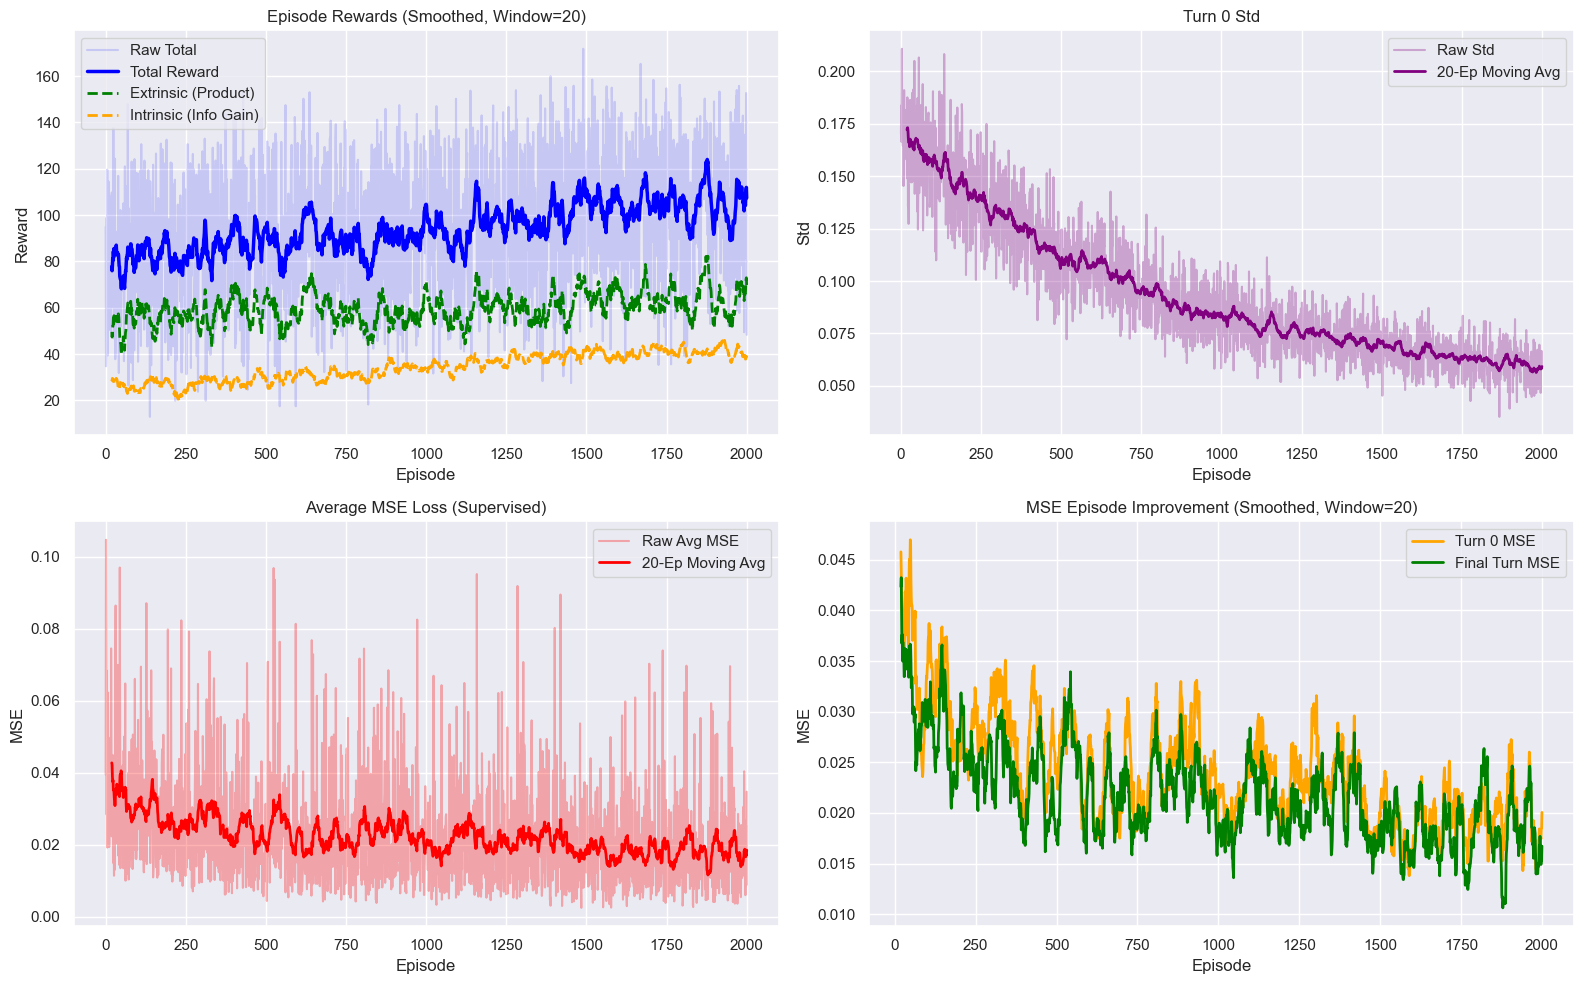

In [465]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes graphs look nicer

def plot_training_metrics(json_path='logs/history.json', smoothing_window=20):
    # 1. Load the data
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
    except FileNotFoundError:
        print(f"Error: Could not find {json_path}. Make sure the path is correct.")
        return

    df = df[df["episode"] <= 2000]
    
    # Check if we have enough data to smooth
    window = min(smoothing_window, max(1, len(df) // 5))

    # 2. Setup the figure layout (2x2 grid)
    sns.set_theme(style="darkgrid")
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    # fig.suptitle('POMDP Agent Training Dashboard', fontsize=16, fontweight='bold')

    # --- Plot 1: Reward Breakdown (Total, Extrinsic, Intrinsic) ---
    # Plot the raw total in the background very faintly
    axs[0, 0].plot(df['episode'], df['total_reward'], alpha=0.15, color='blue', label='Raw Total')
    
    # Plot the smoothed total
    axs[0, 0].plot(df['episode'], df['total_reward'].rolling(window).mean(), color='blue', linewidth=2.5, label='Total Reward')
    
    # Plot the separated rewards (if they exist in the log)
    if 'extrinsic_reward' in df.columns and 'intrinsic_reward' in df.columns:
        axs[0, 0].plot(df['episode'], df['extrinsic_reward'].rolling(window).mean(), color='green', linewidth=2, linestyle='--', label='Extrinsic (Product)')
        axs[0, 0].plot(df['episode'], df['intrinsic_reward'].rolling(window).mean(), color='orange', linewidth=2, linestyle='--', label='Intrinsic (Info Gain)')

    axs[0, 0].set_title(f'Episode Rewards (Smoothed, Window={window})')
    axs[0, 0].set_xlabel('Episode')
    axs[0, 0].set_ylabel('Reward')
    axs[0, 0].legend()

    # --- Plot 2: Turn 0 Variance (Epistemic Uncertainty) ---
    axs[0, 1].plot(df['episode'], df['turn0_var'], alpha=0.3, color='purple', label='Raw Std')
    axs[0, 1].plot(df['episode'], df['turn0_var'].rolling(window).mean(), color='purple', linewidth=2, label=f'{window}-Ep Moving Avg')
    axs[0, 1].set_title('Turn 0 Std')
    axs[0, 1].set_xlabel('Episode')
    axs[0, 1].set_ylabel('Std')
    axs[0, 1].legend()

    # --- Plot 3: Average MSE (Encoder Training Health) ---
    axs[1, 0].plot(df['episode'], df['mse_avg'], alpha=0.3, color='red', label='Raw Avg MSE')
    axs[1, 0].plot(df['episode'], df['mse_avg'].rolling(window).mean(), color='red', linewidth=2, label=f'{window}-Ep Moving Avg')
    axs[1, 0].set_title('Average MSE Loss (Supervised)')
    axs[1, 0].set_xlabel('Episode')
    axs[1, 0].set_ylabel('MSE')
    axs[1, 0].legend()

    # --- Plot 4: Information Gain (Turn 0 vs Final Turn) ---
    # We smooth these directly so the chart isn't a chaotic mess of overlapping lines
    axs[1, 1].plot(df['episode'], df['mse_start'].rolling(window).mean(), color='orange', linewidth=2, label='Turn 0 MSE')
    axs[1, 1].plot(df['episode'], df['mse_end'].rolling(window).mean(), color='green', linewidth=2, label='Final Turn MSE')
    axs[1, 1].set_title(f'MSE Episode Improvement (Smoothed, Window={window})')
    axs[1, 1].set_xlabel('Episode')
    axs[1, 1].set_ylabel('MSE')
    # axs[1, 1].fill_between(df['episode'], 
    #                        df['mse_end'].rolling(window).mean(), 
    #                        df['mse_start'].rolling(window).mean(), 
    #                        color='green', alpha=0.1, label='Knowledge Gained')
    axs[1, 1].legend()

    # 3. Render
    plt.tight_layout()
    # plt.subplots_adjust(top=0.92) # Make room for main title
    plt.show()

# Run it! (Update the filename if yours is different)
plot_training_metrics('logs/history.json', smoothing_window=20)

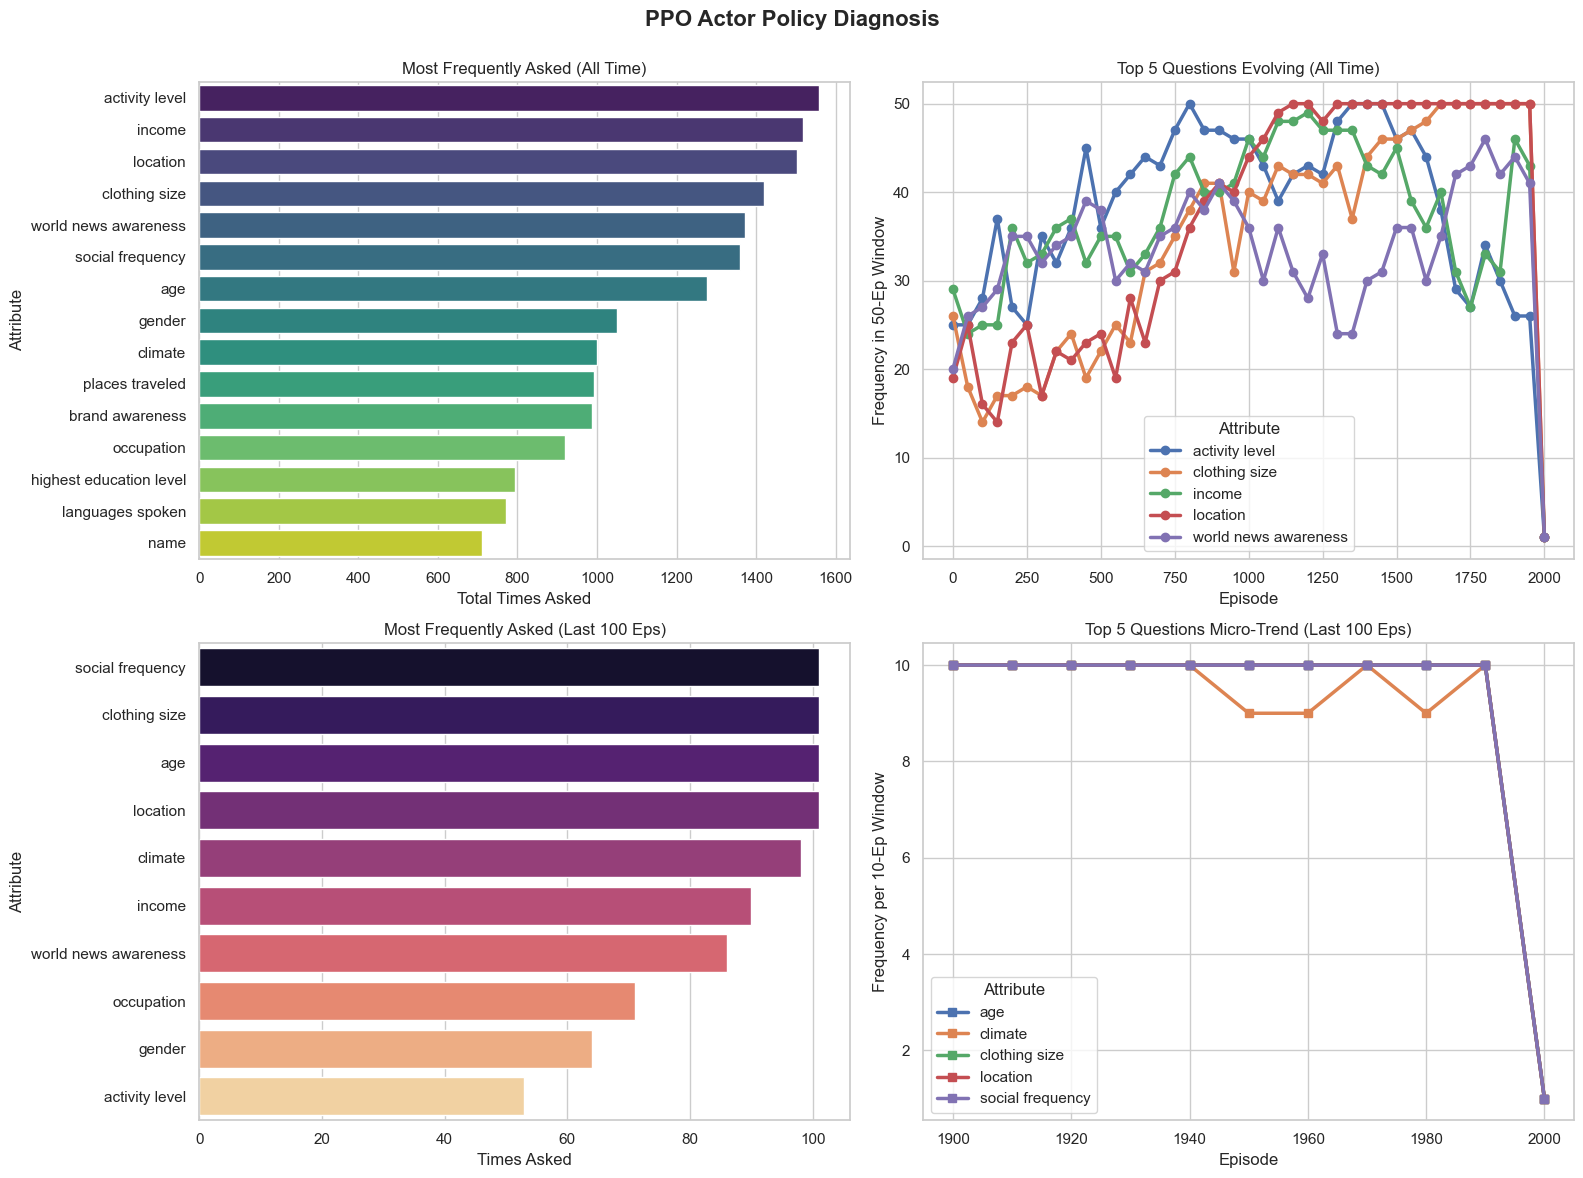

--- Quick Summary ---
Total Episodes Logged: 2000

[ALL TIME] Top 3 Questions:
 - activity level: 1558 times
 - income: 1519 times
 - location: 1504 times

[LAST 100 EPS] Top 3 Questions:
 - social frequency: 101 times
 - clothing size: 101 times
 - age: 101 times


In [466]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def diagnose_actor_behavior(json_path='logs/belief_log.json', recent_window=100):
    # 1. Load and parse the JSON
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Could not find {json_path}")
        return

    extracted_data = []
    for entry in data:
        # Some JSONs have missing keys if they crashed, using .get() is safer
        if "chosen_attr_for_question" in entry:
            extracted_data.append({
                "episode": entry.get("episode"),
                "turn": entry.get("turn"),
                "action": entry.get("chosen_attr_for_question"),
                "std_mean": entry.get("std_mean")
            })
            
    df = pd.DataFrame(extracted_data)
    
    # Check if df is empty
    if df.empty:
        print("No valid action data found in the JSON.")
        return

    df = df[df["episode"] <= 2000]

    # 2. Setup the Plotting Space (Expanded to 2x2)
    sns.set_theme(style="whitegrid")
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('PPO Actor Policy Diagnosis', fontsize=16, fontweight='bold')

    # ==========================================
    # ROW 1: ALL-TIME MACRO TRENDS
    # ==========================================

    # --- Chart 1: Action Frequency (All Episodes) ---
    action_counts = df['action'].value_counts().head(15)
    sns.barplot(x=action_counts.values, y=action_counts.index, ax=axs[0, 0], palette="viridis", hue=action_counts.index, legend=False)
    axs[0, 0].set_title('Most Frequently Asked (All Time)')
    axs[0, 0].set_xlabel('Total Times Asked')
    axs[0, 0].set_ylabel('Attribute')

    # --- Chart 2: Policy Shift Over Time (All Episodes) ---
    top_5_actions = action_counts.head(5).index.tolist()
    filtered_df = df[df['action'].isin(top_5_actions)].copy()
    
    filtered_df['Episode_Bin'] = (filtered_df['episode'] // 50) * 50
    pivot_df = filtered_df.groupby(['Episode_Bin', 'action']).size().unstack(fill_value=0)
    pivot_df.plot(kind='line', marker='o', ax=axs[0, 1], linewidth=2.5)
    
    axs[0, 1].set_title('Top 5 Questions Evolving (All Time)')
    axs[0, 1].set_xlabel('Episode')
    axs[0, 1].set_ylabel('Frequency in 50-Ep Window')
    axs[0, 1].legend(title='Attribute')

    # ==========================================
    # ROW 2: RECENT WINDOW MICRO TRENDS
    # ==========================================
    
    max_ep = df['episode'].max()
    recent_threshold = max(0, max_ep - recent_window)
    recent_df = df[df['episode'] >= recent_threshold].copy()

    # --- Chart 3: Action Frequency (Last X Episodes) ---
    recent_counts = recent_df['action'].value_counts().head(10)
    if not recent_counts.empty:
        sns.barplot(x=recent_counts.values, y=recent_counts.index, ax=axs[1, 0], palette="magma", hue=recent_counts.index, legend=False)
    
    axs[1, 0].set_title(f'Most Frequently Asked (Last {recent_window} Eps)')
    axs[1, 0].set_xlabel('Times Asked')
    axs[1, 0].set_ylabel('Attribute')

    # --- Chart 4: Recent Policy Shift (Micro-trends) ---
    if not recent_df.empty:
        recent_top_5 = recent_counts.head(5).index.tolist()
        recent_filtered = recent_df[recent_df['action'].isin(recent_top_5)].copy()
        
        # Create smaller bins for the recent window (e.g., bins of 10)
        bin_size = max(1, recent_window // 10)
        recent_filtered['Recent_Bin'] = (recent_filtered['episode'] // bin_size) * bin_size
        
        recent_pivot = recent_filtered.groupby(['Recent_Bin', 'action']).size().unstack(fill_value=0)
        recent_pivot.plot(kind='line', marker='s', ax=axs[1, 1], linewidth=2.5)
        
        axs[1, 1].set_title(f'Top 5 Questions Micro-Trend (Last {recent_window} Eps)')
        axs[1, 1].set_xlabel('Episode')
        axs[1, 1].set_ylabel(f'Frequency per {bin_size}-Ep Window')
        axs[1, 1].legend(title='Attribute')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Give the title breathing room
    plt.show()
    
    # Print a quick text summary comparing All-Time to Recent
    print("--- Quick Summary ---")
    print(f"Total Episodes Logged: {max_ep}")
    print(f"\n[ALL TIME] Top 3 Questions:")
    for action, count in action_counts.head(3).items():
        print(f" - {action}: {count} times")
        
    print(f"\n[LAST {recent_window} EPS] Top 3 Questions:")
    for action, count in recent_counts.head(3).items():
        print(f" - {action}: {count} times")

# Run the diagnosis (Looking at the last 100 episodes)
diagnose_actor_behavior('logs/belief_log.json', recent_window=100)

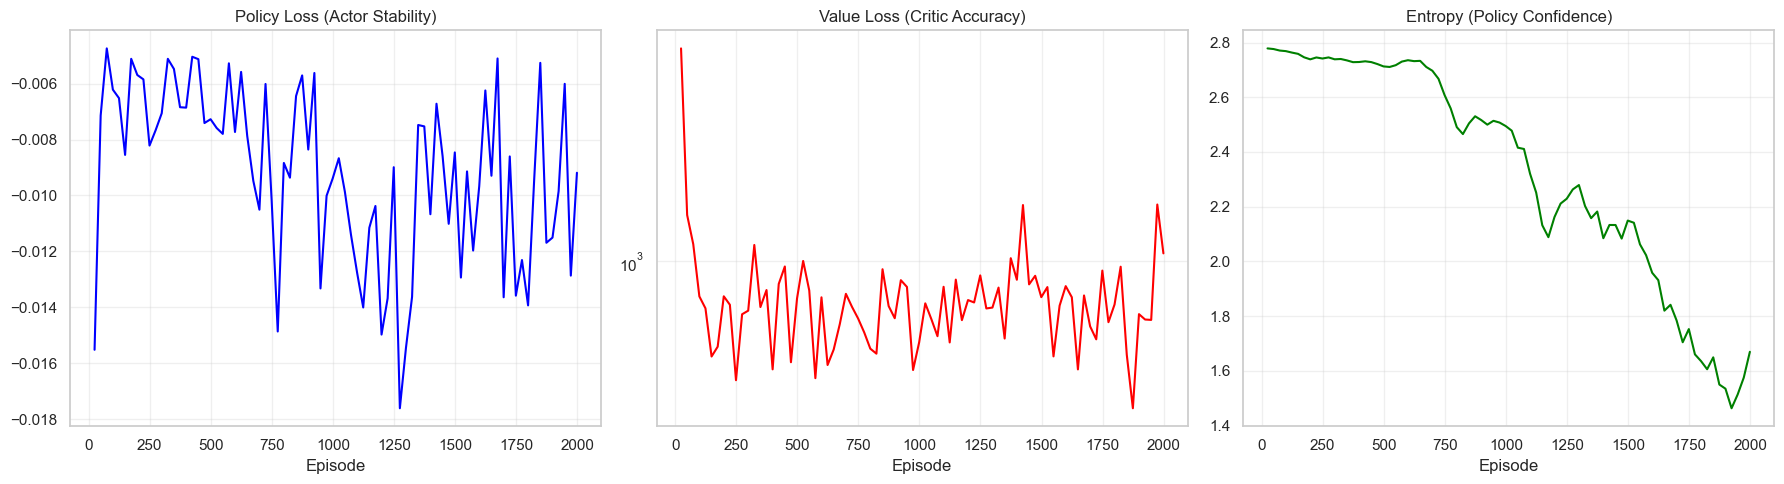

In [467]:
import json
import matplotlib.pyplot as plt
import numpy as np

def visualize_ppo_training(json_path="logs/ppo_metrics.json"):
    with open(json_path, "r") as f:
        data = json.load(f)

    episodes = [d["episode"] for d in data if d["episode"] <= 2000]
    p_loss = [d["policy_loss"] for d in data if d["episode"] <= 2000]
    v_loss = [d["value_loss"] for d in data if d["episode"] <= 2000]
    entropy = [d["entropy"] for d in data if d["episode"] <= 2000]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Policy Loss
    # We look for this to be slightly negative and stable
    axes[0].plot(episodes, p_loss, color='blue', label='Policy Loss')
    axes[0].set_title("Policy Loss (Actor Stability)")
    axes[0].set_xlabel("Episode")
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Value Loss
    # We look for this to trend downward toward zero
    axes[1].plot(episodes, v_loss, color='red', label='Value Loss')
    axes[1].set_title("Value Loss (Critic Accuracy)")
    axes[1].set_xlabel("Episode")
    axes[1].set_yscale('log') # Value loss often starts huge, log scale helps
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Entropy
    # We look for this to decrease, showing the model is becoming "certain"
    axes[2].plot(episodes, entropy, color='green', label='Entropy')
    axes[2].set_title("Entropy (Policy Confidence)")
    axes[2].set_xlabel("Episode")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_ppo_training()